In [1]:
import pandas as pd
dados={
    "paciente_Id":[1,2,3,4,5,6,7,8,9,10],
    "idade":[65,40,72,55,30,80,50,45,60,38],
    "sexo":["M","F","M","F","M","F","M","F","M","F"],
    "setor":["uti","clinica","uti","cirurgica","clinica","uti","cirurgica","clinica","uti","cirurgica"],
    "dias_internação":[12,4,20,6,3,15,7,5,10,4],
    "custo_total":[18000,3500,32000,9000,2800,25000,11000,4000,15000,7000],
    "infecção":["sim","nao","sim","nao","nao","sim","nao","nao","sim","nao"],
    "alta":["alta","alta","obito","alta","alta","obito","alta","alta","alta","alta"]
}
df=pd.DataFrame(dados)
df

,paciente_Id,idade,sexo,setor,dias_internação,custo_total,infecção,alta
0,1,65,M,uti,12,18000,sim,alta
1,2,40,F,clinica,4,3500,nao,alta
2,3,72,M,uti,20,32000,sim,obito
3,4,55,F,cirurgica,6,9000,nao,alta
4,5,30,M,clinica,3,2800,nao,alta
5,6,80,F,uti,15,25000,sim,obito
6,7,50,M,cirurgica,7,11000,nao,alta
7,8,45,F,clinica,5,4000,nao,alta
8,9,60,M,uti,10,15000,sim,alta
9,10,38,F,cirurgica,4,7000,nao,alta


In [2]:
df["dias_internação"].mean()

np.float64(8.6)

In [3]:
df["custo_total"].mean()

np.float64(12730.0)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   paciente_Id      10 non-null     int64 
 1   idade            10 non-null     int64 
 2   sexo             10 non-null     object
 3   setor            10 non-null     object
 4   dias_internação  10 non-null     int64 
 5   custo_total      10 non-null     int64 
 6   infecção         10 non-null     object
 7   alta             10 non-null     object
dtypes: int64(4), object(4)
memory usage: 772.0+ bytes


In [5]:
df["idade"].mean()

np.float64(53.5)

In [6]:
df.describe()


,paciente_Id,idade,dias_internação,custo_total
count,10.00000,10.000000,10.000000,10.00000
mean,5.50000,53.500000,8.600000,12730.00000
std,3.02765,15.918194,5.581716,9801.13939
min,1.00000,30.000000,3.000000,2800.00000
25%,3.25000,41.250000,4.250000,4750.00000
50%,5.50000,52.500000,6.500000,10000.00000
75%,7.75000,63.750000,11.500000,17250.00000
max,10.00000,80.000000,20.000000,32000.00000


In [7]:
df.groupby("setor")["dias_internação"].mean()

,dias_internação
setor,
cirurgica,5.666667
clinica,4.000000
uti,14.250000


In [8]:
df.groupby("setor")["custo_total"].mean()

,custo_total
setor,
cirurgica,9000.000000
clinica,3433.333333
uti,22500.000000


In [9]:
taxa_infecção=(df["infecção"]=="sim").mean()*100
taxa_infecção

np.float64(40.0)

In [10]:
taxa_obito=(df["alta"]=="obito").mean()*100
taxa_obito

np.float64(20.0)

In [11]:
df.groupby("setor")["infecção"].apply(lambda x: (x == "sim").mean() * 100)

,infecção
setor,
cirurgica,0.0
clinica,0.0
uti,100.0


In [12]:
df.groupby("infecção")["dias_internação"].mean()

,dias_internação
infecção,
nao,4.833333
sim,14.250000


In [13]:
df.groupby("infecção")["custo_total"].mean()

,custo_total
infecção,
nao,6216.666667
sim,22500.000000


In [14]:
df["dias_internação"].corr(df["custo_total"])

np.float64(0.990363634802682)

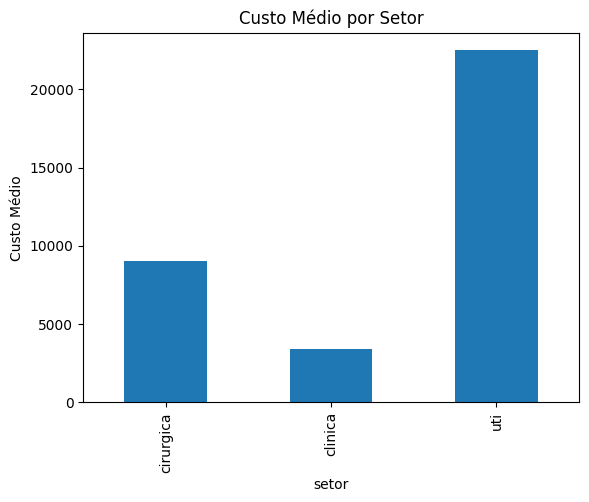

In [15]:
import matplotlib.pyplot as plt

df.groupby("setor")["custo_total"].mean().plot(kind="bar")
plt.title("Custo Médio por Setor")
plt.ylabel("Custo Médio")
plt.show()

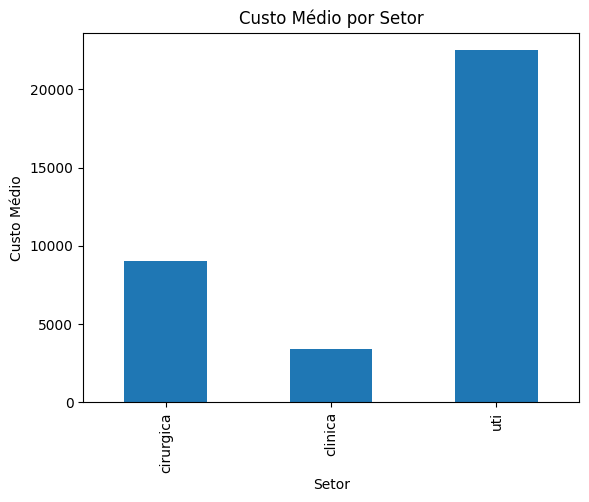

In [16]:
import matplotlib.pyplot as plt

df.groupby("setor")["custo_total"].mean().plot(kind="bar")
plt.title("Custo Médio por Setor")
plt.xlabel("Setor")
plt.ylabel("Custo Médio")
plt.show()

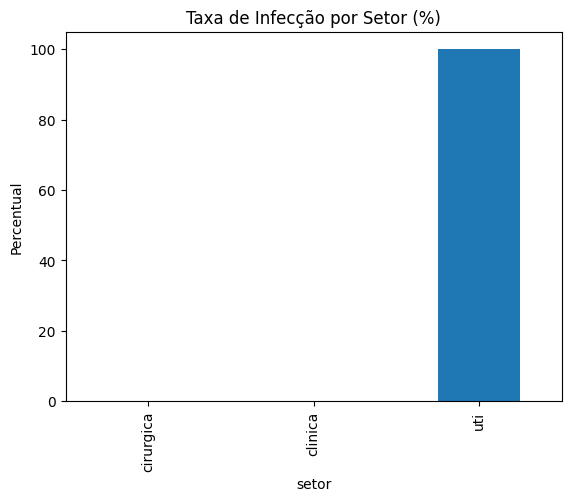

In [18]:
taxa_setor = df.groupby("setor")["infecção"].apply(lambda x: (x == "sim").mean() * 100)

taxa_setor.plot(kind="bar")
plt.title("Taxa de Infecção por Setor (%)")
plt.ylabel("Percentual")
plt.show()

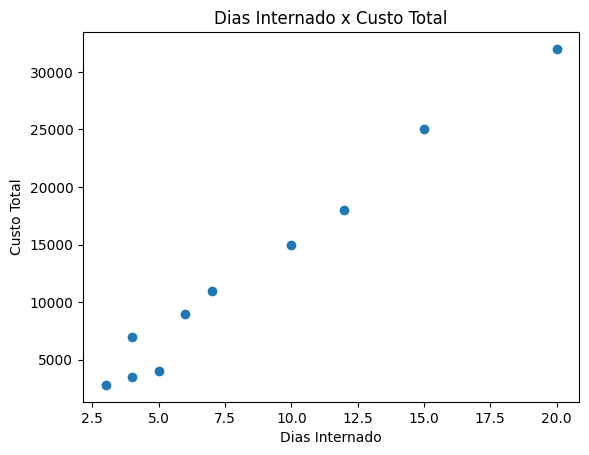

In [20]:
plt.scatter(df["dias_internação"], df["custo_total"])
plt.title("Dias Internado x Custo Total")
plt.xlabel("Dias Internado")
plt.ylabel("Custo Total")
plt.show()

In [22]:
custo_com_inf = df[df["infecção"] == "sim"]["custo_total"].mean()
custo_sem_inf = df[df["infecção"] == "nao"]["custo_total"].mean()

diferenca = custo_com_inf - custo_sem_inf
diferenca

np.float64(16283.333333333332)